In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import scipy
import scipy.linalg
import math
from tqdm import tqdm
import gaussian_crossings.utils as utils
import gaussian_crossings.formula as formula
import gaussian_crossings.process as process
from matplotlib.ticker import FuncFormatter, LogLocator, MaxNLocator

In [2]:
# Simulation parameters.
T = 10.0                         # Total simulation time.
omega0 = math.sqrt(10.0)                   # Fundamental frequency
zeta = 0.5                      # Damping ratio
temp = 10.0                     # Temperature (similar to sigma ** 2)
u = 0.25

if zeta < 1.0:
    dt = 0.01 / (omega0 * max(zeta, math.sqrt(1 - zeta**2)))  
elif zeta == 1.0:
    dt = 0.01 / omega0
else:
    dt = 0.01 / (omega0 * max(zeta + math.sqrt(zeta**2 - 1), zeta - math.sqrt(zeta**2 - 1)))

In [3]:
model = formula.GaussianUpCrossings(r_func=process.r_damped_harmonic_oscillator_noise, u=u, temp=temp, zeta=zeta, omega0=omega0)

In [4]:
print(model.upcrossing_variance(T))

tensor(1.8783)


In [5]:
epsilon_left=1e-5
num_points=1000

t_prime = torch.linspace(epsilon_left, T / (1 + T), num_points)
x = t_prime / (1 - t_prime)
new_integrand_vals = (1 - x / T) * model.upcrossing_integrand(x, u=u) / (1 - t_prime)**2
left_limit = - (1 / (4 * torch.pi**2)) * (model.q0 / model.r0) * torch.exp(-(u**2) / model.r0)
integral = epsilon_left * left_limit + torch.trapz(new_integrand_vals[~torch.isnan(new_integrand_vals)], t_prime[~torch.isnan(new_integrand_vals)])

print(T * (model.upcrossing_mean_rate(u=u) + 2 * integral))

tensor(1.8783)


In [6]:
print(left_limit)

tensor(-0.2380)


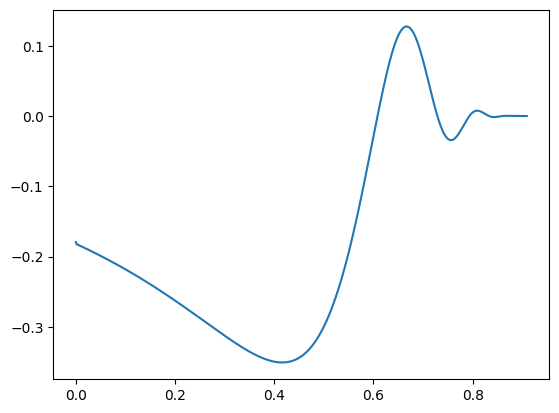

In [7]:
plt.plot(t_prime, new_integrand_vals)
plt.show()